# Environment Setup

In [ ]:
import os
import time
import string
import random
import datetime
from pathlib import Path
from dotenv import load_dotenv
from IPython.display import Audio
from tqdm.auto import tqdm

import wandb
import torch
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import (
    ClapModel,
    ClapProcessor,
    TrainingArguments,
    AutoModel,
    AutoTokenizer,
    Trainer,
    EarlyStoppingCallback,
    TrainerCallback,
)
from datasets import load_dataset, concatenate_datasets, Audio as HfAudio
from huggingface_hub import login as hf_login
from google.colab import userdata


HF_TOKEN = userdata.get("HF_TOKEN")
WANDB_PROJECT_NAME = "audio_learning"
WANDB_API_KEY = userdata.get("WANDB_API_KEY")

wandb.login(key=WANDB_API_KEY)
hf_login(HF_TOKEN)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: octoopt to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


# Experiment

In [ ]:
PROJECT_NAME = "clap-finetuning"
DEFAULT_SAMPLE_RATE = 48_000  # CLAP default
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
def get_run_name(prefix, lr: float = 2e-5, batch_size: int = 256):
    now = datetime.datetime.now().strftime("%m%d-%H%M")
    # Example: CLAP-VN_lr1e-5_bs32_0216-1650
    return f"{prefix}_lr{lr}_bs{batch_size}_{now}"


get_run_name(prefix=PROJECT_NAME)

'clap-finetuning_lr2e-05_bs256_0226-1358'

## Dataset

In [ ]:
"""
Hugging Face's dataset id
- Achilles822/viedata82 # https://huggingface.co/datasets/Achilles822/viedata82
- shunyalabs/vietnamese-speech-dataset # https://huggingface.co/datasets/shunyalabs/vietnamese-speech-dataset
- dolly-vn/dolly-audio-1000h-vietnamese # https://huggingface.co/datasets/dolly-vn/dolly-audio-1000h-vietnamese
- hungkieu/vietnamese-voices # https://huggingface.co/datasets/hungkieu/vietnamese-voices
- Tinnn-vn/vietnamese-tts-dataset # https://huggingface.co/datasets/Tinnn-vn/vietnamese-tts-dataset

- trivitaai/vietnamese-spoken-normalization # https://huggingface.co/datasets/trivitaai/vietnamese-spoken-normalization
- trivitaai/VTVGo_Speech_Dataset # https://huggingface.co/datasets/trivitaai/VTVGo_Speech_Dataset
- trivitaai/VTVGo_Speech_Dataset_2 # https://huggingface.co/datasets/trivitaai/VTVGo_Speech_Dataset_2
- vinhainsec/vlsp2023-vietnamese-asr # https://huggingface.co/datasets/vinhainsec/vlsp2023-vietnamese
"""


dataset_ids = [
    # "Achilles822/viedata82",
    # "shunyalabs/vietnamese-speech-dataset",
    # "hungkieu/vietnamese-voices",
    # "vinhainsec/vlsp2023-vietnamese-asr"
    "trivitaai/VTVGo_Speech_Dataset_3"
]

ds_01 = load_dataset(dataset_ids[0])
# ds_02 = load_dataset(dataset_ids[1])
# ds_03 = load_dataset(dataset_ids[2])
# ds_04 = load_dataset(dataset_ids[3])

print(ds_01)
# print(ds_02)
# print(ds_03)
# print(ds_04)

README.md:   0%|          | 0.00/475 [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/57 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/57 [00:00<?, ?it/s]

data/train-00000-of-00057.parquet:   0%|          | 0.00/479M [00:00<?, ?B/s]

data/train-00001-of-00057.parquet:   0%|          | 0.00/482M [00:00<?, ?B/s]

...

data/train-00055-of-00057.parquet:   0%|          | 0.00/474M [00:00<?, ?B/s]

data/train-00056-of-00057.parquet:   0%|          | 0.00/522M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/42761 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/53 [00:00<?, ?it/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'audio_clean', 'audio_noisy', 'duration'],
        num_rows: 42761
    })
})


In [ ]:
ds_01 = ds_01.rename_column("audio_clean", "audio")
# ds_03 = ds_03.rename_column("transcript", "text")

In [ ]:
all_splits = []

for split in ds_01.keys():
    temp_ds = ds_01[split].select_columns(["audio", "text"])
    temp_ds = temp_ds.cast_column("audio", HfAudio(sampling_rate=DEFAULT_SAMPLE_RATE))
    all_splits.append(temp_ds)


# for split in ds_02.keys():
#     temp_ds = ds_02[split].select_columns(['audio', 'text'])
#     temp_ds = temp_ds.cast_column("audio", HfAudio(sampling_rate=DEFAULT_SAMPLE_RATE))
#     all_splits.append(temp_ds)


# for split in ds_03.keys():
#     temp_ds = ds_03[split].select_columns(['audio', 'text'])
#     temp_ds = temp_ds.cast_column("audio", HfAudio(sampling_rate=DEFAULT_SAMPLE_RATE))
#     all_splits.append(temp_ds)

# for split in ds_04.keys():
#     temp_ds = ds_04[split].select_columns(['audio', 'text'])
#     temp_ds = temp_ds.cast_column("audio", HfAudio(sampling_rate=DEFAULT_SAMPLE_RATE))
#     all_splits.append(temp_ds)


print(f"Total samples: {len(all_splits)}")

Total samples: 1


In [ ]:
# 2. Merge everything into one Master Pool
master_dataset = concatenate_datasets(all_splits)

# 3. Perform a Global Shuffle and Split
# We'll use 80% for training and 20% for evaluation
final_split = master_dataset.shuffle(seed=42).train_test_split(test_size=0.2, seed=42)

train_ds = final_split["train"]
eval_ds = final_split["test"]

print(f"✅ Merging Complete!")
print(f"Total Combined Samples: {len(master_dataset)}")
print(f"Training Samples: {len(train_ds)}")
print(f"Evaluation Samples: {len(eval_ds)}")

✅ Merging Complete!
Total Combined Samples: 42761
Training Samples: 34208
Evaluation Samples: 8553


In [ ]:
eval_ds

Dataset({
    features: ['audio', 'text'],
    num_rows: 8553
})

In [ ]:
sample = eval_ds[0]
print(sample)

print(f"Metadata: {sample['audio'].metadata}")
print(f"Stream Index: {sample['audio'].stream_index}")
print(f"All Samples: {sample['audio'].get_all_samples()}")
print(f"Samples in Range: {sample['audio'].get_samples_played_in_range()}")

{'audio': <datasets.features._torchcodec.AudioDecoder object at 0x7bb418edebd0>, 'text': 'Em Việt ra đây.'}
Metadata: AudioStreamMetadata:
  duration_seconds_from_header: 0.72
  begin_stream_seconds_from_header: None
  bit_rate: 256000.0
  codec: pcm_s16le
  stream_index: 0
  duration_seconds: 0.72
  begin_stream_seconds: 0.0
  sample_rate: 16000
  num_channels: 1
  sample_format: s16

Stream Index: 0
All Samples: AudioSamples:
  data (shape): torch.Size([1, 34560])
  pts_seconds: 0.0
  duration_seconds: 0.72
  sample_rate: 48000

Samples in Range: AudioSamples:
  data (shape): torch.Size([1, 34560])
  pts_seconds: 0.0
  duration_seconds: 0.72
  sample_rate: 48000



In [ ]:
audio_data = sample["audio"]["array"]
Audio(audio_data, rate=DEFAULT_SAMPLE_RATE)

In [ ]:
y_clean = sample["audio"]["array"]
y_noisy = sample["audio"]["array"]
sr = sample["audio"]["sampling_rate"]

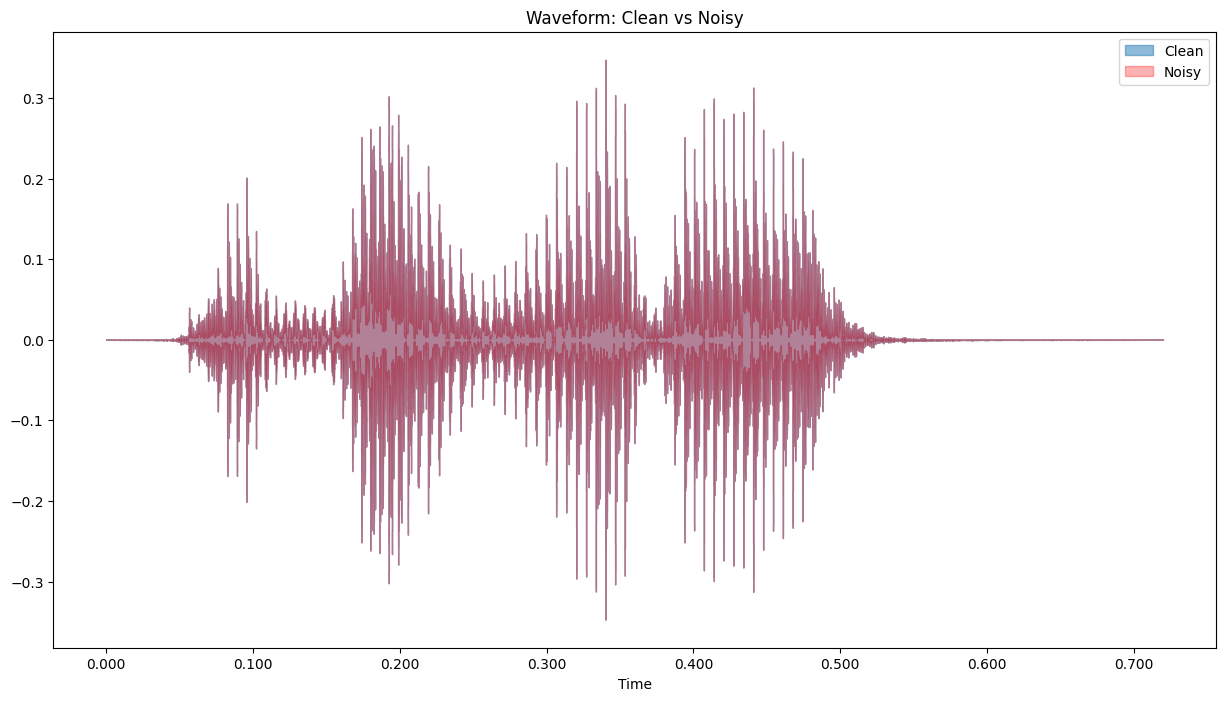

In [ ]:
# 2. Time-Domain Analysis (Waveforms)
plt.figure(figsize=(15, 8))
# plt.subplot(3, 1, 1)
librosa.display.waveshow(y_clean, sr=sr, alpha=0.5, label="Clean")
librosa.display.waveshow(y_noisy, sr=sr, color="r", alpha=0.3, label="Noisy")
plt.title("Waveform: Clean vs Noisy")
plt.legend()

In [ ]:
# 3. Frequency-Domain Analysis (Mel-Spectrograms)
S_clean = librosa.feature.melspectrogram(y=y_clean, sr=sr, n_mels=128)
S_dB_clean = librosa.power_to_db(S_clean, ref=np.max)
S_noisy = librosa.feature.melspectrogram(y=y_noisy, sr=sr, n_mels=128)
S_dB_noisy = librosa.power_to_db(S_noisy, ref=np.max)

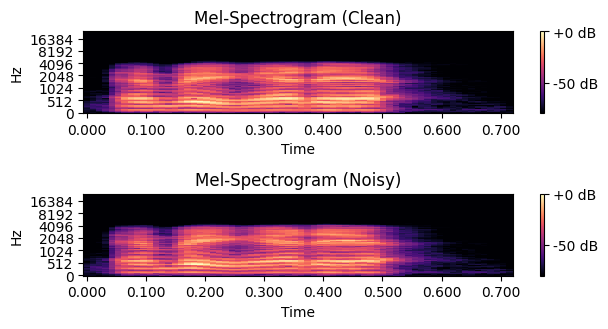

In [ ]:
plt.subplot(3, 1, 2)
librosa.display.specshow(S_dB_clean, x_axis="time", y_axis="mel", sr=sr)
plt.colorbar(format="%+2.0f dB")
plt.title("Mel-Spectrogram (Clean)")
plt.subplot(3, 1, 3)
librosa.display.specshow(S_dB_noisy, x_axis="time", y_axis="mel", sr=sr)
plt.colorbar(format="%+2.0f dB")
plt.title("Mel-Spectrogram (Noisy)")
plt.tight_layout()
plt.show()

In [ ]:
# 4. Statistical Metrics
rms_clean = np.sqrt(np.mean(y_clean**2))
rms_noisy = np.sqrt(np.mean(y_noisy**2))
snr = 20 * np.log10(rms_clean / (rms_noisy - rms_clean + 1e-10))

print(f"--- Statistics ---")
print(f"Duration: {len(y_clean) / sr:.2f} seconds")
print(f"RMS Energy (Clean): {rms_clean:.4f}")
print(f"RMS Energy (Noisy): {rms_noisy:.4f}")
print(f"Estimated SNR: {snr:.2f} dB")

--- Statistics ---
Duration: 0.72 seconds
RMS Energy (Clean): 0.0481
RMS Energy (Noisy): 0.0481
Estimated SNR: 173.65 dB


In [ ]:
# # 1. Collect Global Stats
# stats = []

# print("Analyzing dataset...")
# for sample in tqdm(train_ds):
#     y_clean = sample["audio"]["array"]
#     sr = sample["audio"]["sampling_rate"]

#     # Calculate Metrics
#     duration = len(y_clean) / sr
#     word_count = len(sample["text"].split())
#     rms_clean = np.sqrt(np.mean(y_clean**2))

#     stats.append(
#         {
#             "duration": duration,
#             "word_count": word_count,
#             "rms_clean": rms_clean,
#         }
#     )

# df_stats = pd.DataFrame(stats)

# # 2. Visualize distributions
# plt.figure(figsize=(18, 5))

# # Plot 1: Duration Distribution
# plt.subplot(1, 3, 1)
# sns.histplot(df_stats["duration"], bins=20, kde=True, color="skyblue")
# plt.title("Audio Duration Distribution")
# plt.xlabel("Seconds")

# # Plot 2: Text-Audio Correlation
# plt.subplot(1, 3, 2)
# sns.scatterplot(data=df_stats, x="duration", y="word_count", alpha=0.6)
# sns.regplot(data=df_stats, x="duration", y="word_count", scatter=False, color="red")
# plt.title("Text Length vs. Audio Duration")

# plt.tight_layout()
# plt.show()

# # 3. Print Overview
# print(f"Dataset Mean Duration: {df_stats['duration'].mean():.2f}s")


## Fine-Tuning

In [ ]:
model_id = "laion/clap-htsat-fused"
model = ClapModel.from_pretrained(model_id)
processor = ClapProcessor.from_pretrained(model_id)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/614M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/477 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/537 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

In [ ]:
audio_data = [sample["audio"]["array"]]  # Simulated 3s audio at 16kHz
text_data = [sample["text"]]
inputs = processor(
    text=text_data,
    audio=audio_data,
    return_tensors="pt",
    sampling_rate=DEFAULT_SAMPLE_RATE,
    padding=True,
)
inputs

{'input_features': tensor([[[[ -36.5521,  -39.6554,  -43.7400,  ...,  -95.4428,  -96.3321,
            -97.1443],
          [ -59.1925,  -53.2849,  -40.5469,  ..., -100.0000, -100.0000,
           -100.0000],
          [ -41.5965,  -38.3425,  -36.9209,  ..., -100.0000, -100.0000,
           -100.0000],
          ...,
          [-100.0000, -100.0000, -100.0000,  ..., -100.0000, -100.0000,
           -100.0000],
          [-100.0000, -100.0000, -100.0000,  ..., -100.0000, -100.0000,
           -100.0000],
          [-100.0000, -100.0000, -100.0000,  ..., -100.0000, -100.0000,
           -100.0000]],

         [[ -36.5521,  -39.6554,  -43.7400,  ...,  -95.4428,  -96.3321,
            -97.1443],
          [ -59.1925,  -53.2849,  -40.5469,  ..., -100.0000, -100.0000,
           -100.0000],
          [ -41.5965,  -38.3425,  -36.9209,  ..., -100.0000, -100.0000,
           -100.0000],
          ...,
          [-100.0000, -100.0000, -100.0000,  ..., -100.0000, -100.0000,
           -100.0000],

In [ ]:
# processor.feature_extractor.truncation = "fusion"


def preprocess_function(samples):
    # 1. Handle the inputs based on whether it's a batch or single item
    if isinstance(samples["text"], list):
        text_inputs = samples["text"]
        audio_arrays = [x["array"] for x in samples["audio"]]
    else:
        text_inputs = samples["text"]
        audio_arrays = samples["audio"]["array"]

    # 2. Call processor without passing 'truncation' as a top-level arg
    # The processor will use the 'fusion' strategy for audio
    # because you set it globally: processor.feature_extractor.truncation = "fusion"
    inputs = processor(
        text=text_inputs,
        audio=audio_arrays,
        sampling_rate=DEFAULT_SAMPLE_RATE,
        return_tensors="pt",
        padding="max_length",
    )

    # 3. Standardize the output for the Trainer
    input_features = inputs["input_features"].squeeze(0)

    return {
        "input_ids": inputs["input_ids"].squeeze(0),
        "attention_mask": inputs["attention_mask"].squeeze(0),
        "input_features": input_features,
        "is_longer": inputs["is_longer"].squeeze(0),
    }

In [ ]:
ppr_sample = preprocess_function(eval_ds[0])
print(ppr_sample.keys())
print(f"Input features shape: {ppr_sample['input_features'].shape}")

dict_keys(['input_ids', 'attention_mask', 'input_features', 'is_longer'])
Input features shape: torch.Size([4, 1001, 64])


In [ ]:
def compute_metrics(eval_pred):
    # Since prediction_step now returns ONLY (audio, text), we unpack just 2 items
    audio_embeds, text_embeds = eval_pred.predictions

    # Debug Print: Verify shapes to ensure data is flowing
    print(f"\n🔍 Metric check - Audio: {audio_embeds.shape}, Text: {text_embeds.shape}")

    # Similarity Matrix (NumPy)
    sim_matrix = np.matmul(text_embeds, audio_embeds.T)
    labels = np.arange(len(text_embeds))

    # Ranking
    inds = np.argsort(-sim_matrix, axis=1)
    ranks = [np.where(inds[i] == labels[i])[0][0] for i in range(len(inds))]
    ranks = np.array(ranks)

    # Metrics
    mAP = np.mean(1.0 / (ranks + 1)) * 100.0
    r1 = 100.0 * np.mean(ranks < 1)
    r10 = 100.0 * np.mean(ranks < 10)

    results = {
        "mAP": mAP,
        "recall_at_1": r1,
        "recall_at_10": r10,
    }

    print(f"✅ Results: {results}")
    return results


class ClapTrainer(Trainer):
    def compute_loss(
        self, model, inputs, return_outputs=False, num_items_in_batch=None
    ):
        outputs = model(**inputs)

        # Symmetric Loss Calculation
        logits_per_audio = outputs.logits_per_audio
        logits_per_text = outputs.logits_per_text

        # Create labels on the correct device
        labels = torch.arange(logits_per_audio.shape[0], device=logits_per_audio.device)

        loss_a = torch.nn.functional.cross_entropy(logits_per_audio, labels)
        loss_t = torch.nn.functional.cross_entropy(logits_per_text, labels)
        loss = (loss_a + loss_t) / 2

        return (loss, outputs) if return_outputs else loss

    # def prediction_step(self, model, inputs, prediction_loss_only, ignore_keys=None):
    #     inputs = self._prepare_inputs(inputs)

    #     with torch.no_grad():
    #         outputs = model(**inputs)
    #         loss = outputs.loss if hasattr(outputs, "loss") else None

    #     if prediction_loss_only:
    #         return (loss, None, None)

    #     # Extract Embeddings
    #     # Detach and move to CPU to ensure Trainer can convert to NumPy safely
    #     audio_embeds = outputs.audio_embeds.detach()
    #     text_embeds = outputs.text_embeds.detach()

    #     # RETURN ONLY WHAT WE NEED
    #     # No dummy tensors. Just the tuple of embeddings.
    #     return (loss, (audio_embeds, text_embeds), None)

    def prediction_step(self, model, inputs, prediction_loss_only, ignore_keys=None):
        inputs = self._prepare_inputs(inputs)

        with torch.no_grad():
            outputs = model(**inputs)
            loss = outputs.loss if hasattr(outputs, "loss") else None

        if prediction_loss_only:
            return (loss, None, None)

        audio_embeds = outputs.audio_embeds.detach()
        text_embeds = outputs.text_embeds.detach()

        # Create a dummy label tensor so the Trainer doesn't think the batch is empty
        # This matches the shape of your embeddings' batch size
        dummy_labels = torch.zeros(audio_embeds.shape[0], device=audio_embeds.device)

        return (loss, (audio_embeds, text_embeds), dummy_labels)

In [ ]:
# os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
BATCH_SIZE = 118
LEARNING_RATE = 2e-5
EPOCH = 20
training_args = TrainingArguments(
    output_dir="./checkpoints",
    # ====================================================
    # 🚀 TRANING PARAMS
    # ====================================================
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    # 64 batch * 8 accumulation = 512 Effective Batch Size
    gradient_accumulation_steps=8,
    # ====================================================
    # ⚡ MEMORY & SPEED SAVERS
    # ====================================================
    bf16=True,  # Native A100 precision (better than fp16)
    tf32=True,  # Tensor Core acceleration
    # ====================================================
    # ⚙️ WORKER & DATA SAFETY
    # ====================================================
    dataloader_num_workers=4,  # 4 is the balance between CPU load and GPU feed
    dataloader_pin_memory=True,  # Faster transfer to GPU
    dataloader_drop_last=True,  # PREVENTS CRASH: Drops uneven last batch (BatchNorm fix)
    remove_unused_columns=False,  # PREVENTS CRASH: Keeps 'is_longer' logic alive
    # ====================================================
    # 🧠 OPTIMIZER & SCHEDULER
    # ====================================================
    num_train_epochs=EPOCH,
    learning_rate=LEARNING_RATE,
    warmup_steps=36,
    weight_decay=0.02,
    lr_scheduler_type="cosine",
    optim="adamw_torch_fused",
    # ====================================================
    # 📈 EVALUATION & METRICS (The Fix for [])
    # ====================================================
    # CRITICAL: Forces Trainer to save embeddings for compute_metrics
    prediction_loss_only=False,
    eval_strategy="epoch",  # Evaluate at the end of every epoch
    save_strategy="epoch",  # Save a checkpoint at the end of every epoch
    save_total_limit=3,  # Keeps the 3 most recent/best checkpoints
    # eval_strategy="steps",
    eval_steps=100,  # Evaluate every ~5 epochs
    save_steps=100,
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="eval_mAP",  # Must match your compute_metrics key
    greater_is_better=True,
    report_to="wandb",
    seed=42,
)

In [ ]:
%timeit

# Normalize dataset before use
train_dataset = train_ds.map(
    preprocess_function, batched=False, remove_columns=train_ds.column_names
)

eval_dataset = eval_ds.map(
    preprocess_function, batched=False, remove_columns=eval_ds.column_names
)

Map:   0%|          | 0/34208 [00:00<?, ? examples/s]

Map:   0%|          | 0/8553 [00:00<?, ? examples/s]

In [ ]:
ppr_sample = preprocess_function(eval_ds[0])
print(ppr_sample.keys())
print(f"Input features shape: {ppr_sample['input_features'].shape}")

dict_keys(['input_ids', 'attention_mask', 'input_features', 'is_longer'])
Input features shape: torch.Size([4, 1001, 64])


In [ ]:
class ClapDataCollator:
    def __call__(self, features):
        batch = {}

        # 1. Stack Text components
        batch["input_ids"] = torch.stack(
            [torch.tensor(f["input_ids"]) for f in features]
        )
        batch["attention_mask"] = torch.stack(
            [torch.tensor(f["attention_mask"]) for f in features]
        )

        # 2. Stack Audio features [Batch, 4, 1001, 64]
        # We don't squeeze here because the preprocessor already did it
        batch["input_features"] = torch.stack(
            [torch.tensor(f["input_features"]) for f in features]
        )

        # 3. Stack the Metadata (Crucial for Fusion logic)
        batch["is_longer"] = torch.stack(
            [torch.tensor(f["is_longer"]) for f in features]
        )

        return batch


data_collator = ClapDataCollator()

In [ ]:
early_stopping = EarlyStoppingCallback(
    early_stopping_patience=3, early_stopping_threshold=0.001
)

data_collator = ClapDataCollator()

In [ ]:
# import torch
# import gc

# # Clear GPU cache
# torch.cuda.empty_cache()
# # Run garbage collector
# gc.collect()

# # Verify memory is cleared
# print(f"Allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
# print(f"Reserved:  {torch.cuda.memory_reserved() / 1024**3:.2f} GB")

# model = ClapModel.from_pretrained(model_id)
# model


Allocated: 2.42 GB
Reserved:  3.58 GB


Loading weights:   0%|          | 0/477 [00:00<?, ?it/s]

ClapModel(
  (text_model): ClapTextModel(
    (embeddings): ClapTextEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): ClapTextEncoder(
      (layer): ModuleList(
        (0-11): 12 x ClapTextLayer(
          (attention): ClapTextAttention(
            (self): ClapTextSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): ClapTextSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm):

In [ ]:
# 1. Define specific run parameters for the name
lr = training_args.learning_rate
bs = training_args.per_device_train_batch_size
full_run_name = get_run_name(f"{PROJECT_NAME}-VN", lr, bs)
full_run_name

# 2. Initialize WandB once
# We use 'reinit=True' in case you run this in a notebook cell multiple times
wandb.init(
    project=PROJECT_NAME,
    name=full_run_name,
    notes="Verification of single batch + CLAP training start",
)

# 3. Final verification of a single batch
try:
    sample_batch = data_collator([train_dataset[0], train_dataset[1]])
    print("✅ Collator verification passed!")
    # Step-by-step check: Ensure shapes match CLAP expectations
    # Typically: [Batch, Seq_Len] for text and [Batch, Audio_Dim, Time] for features
    print(
        f"Batch shapes -> IDs: {sample_batch['input_ids'].shape}, Audio: {sample_batch['input_features'].shape}"
    )
except Exception as e:
    print(f"❌ Collator failure: {e}")
    wandb.finish()  # Close the run if the check fails
    raise e

training_args.prediction_loss_only = False
training_args.metric_for_best_model = "eval_mAP"

# 4. Start the Trainer`
trainer = ClapTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    # data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping],
)

# 5. Launch Training
trainer.train()

# 6. Final Cleanup
wandb.finish()

✅ Collator verification passed!
Batch shapes -> IDs: torch.Size([2, 512]), Audio: torch.Size([2, 4, 1001, 64])


Epoch,Training Loss,Validation Loss,Map,Recall At 1,Recall At 10
1,3.825243,No log,0.378201,0.035311,0.482580
2,3.289780,No log,0.737225,0.176554,1.153484
3,3.081639,No log,0.766198,0.176554,1.294727
4,3.083994,No log,1.191795,0.247175,2.189266
5,2.879664,No log,1.202295,0.294256,2.165725
6,2.768045,No log,1.267249,0.341337,2.212806
7,2.620593,No log,2.054501,0.553202,4.154896
8,2.452054,No log,1.845176,0.411959,3.884181
9,2.332747,No log,2.186845,0.553202,4.413842
10,2.208552,No log,3.178274,0.929849,6.661959



🔍 Metric check - Audio: (8496, 512), Text: (8496, 512)
✅ Results: {'mAP': np.float64(0.37820140715354317), 'recall_at_1': np.float64(0.03531073446327684), 'recall_at_10': np.float64(0.4825800376647834)}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


🔍 Metric check - Audio: (8496, 512), Text: (8496, 512)
✅ Results: {'mAP': np.float64(0.7372247144116735), 'recall_at_1': np.float64(0.1765536723163842), 'recall_at_10': np.float64(1.1534839924670435)}


...


🔍 Metric check - Audio: (8496, 512), Text: (8496, 512)
✅ Results: {'mAP': np.float64(4.824574528742293), 'recall_at_1': np.float64(1.612523540489642), 'recall_at_10': np.float64(10.193032015065913)}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


🔍 Metric check - Audio: (8496, 512), Text: (8496, 512)
✅ Results: {'mAP': np.float64(4.793797613623849), 'recall_at_1': np.float64(1.6360640301318268), 'recall_at_10': np.float64(10.204802259887005)}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
import os
from huggingface_hub import HfApi, login


USERNAME = "minhleduc"
REPO_NAME = "clap-finetuned-vn-002"
REPO_ID = f"{USERNAME}/{REPO_NAME}"
CHECKPOINT_ROOT = "./checkpoints"

# ==========================================
# 🏆 2. FIND BEST CHECKPOINT
# ==========================================
# This automatically finds the folder with the highest step number
if not os.path.exists(CHECKPOINT_ROOT):
    raise FileNotFoundError("Checkpoints folder not found!")

checkpoints = [d for d in os.listdir(CHECKPOINT_ROOT) if d.startswith("checkpoint")]
if not checkpoints:
    raise FileNotFoundError("No checkpoints found!")

# Sort by step number (e.g., checkpoint-500, checkpoint-1000)
checkpoints = sorted(checkpoints, key=lambda x: int(x.split("-")[-1]))
best_checkpoint_path = os.path.join(CHECKPOINT_ROOT, checkpoints[-1])

print(f"🎯 Target Checkpoint: {best_checkpoint_path}")

# ==========================================
# ⚙️ 3. SAVE PROCESSOR (CRITICAL!)
# ==========================================
# The Trainer saves the model weights, but often forgets the processor config.
# We manually save it into the checkpoint folder so users can load it easily.
print("📝 Bundling processor files...")
processor.save_pretrained(best_checkpoint_path)

# ==========================================
# 🚀 4. UPLOAD TO HUB
# ==========================================
api = HfApi()

# Create the repo if it doesn't exist (Private by default for safety)
api.create_repo(repo_id=REPO_ID, exist_ok=True, private=True)

print(f"⬆️  Uploading to https://huggingface.co/{REPO_ID} ...")

api.upload_folder(
    folder_path=best_checkpoint_path,
    repo_id=REPO_ID,
    commit_message=f"Upload best checkpoint: {checkpoints[-1]}",
    ignore_patterns=[
        "optimizer.pt",
        "scheduler.pt",
        "rng_state.pth",
        "trainer_state.json",
    ],
)

print("✅ Upload Complete! Your model is live.")

FileNotFoundError: No checkpoints found!